# GRIZZLY — fixed HERA observation + Wiener denoising

Single GRIZZLY snapshot run through one fixed observation (no sweep). The observation
follows the settings from notebook `01` (HERA-350, 14 m dish, wedge slope 1.0), but
with integration time **1 h/day × 360 days** (= 2 × 180 d at 1 h instead of 6 h).

Focus:
1. Build the noise filter `f_noise(k_perp, k_par)` and the wedge-masked
   `f_total = f_noise × f_wedge` (the bottom-right two panels of the old 6-panel figure).
2. Apply the Wiener filter to the noisy observed cube to denoise it.
3. Show brightness-temperature maps: clean → noisy → Wiener-denoised.

In [61]:
%load_ext autoreload
%autoreload 2
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import scipy.fft as fft
from astropy import units as un

from tuesday.core import (
    observe_coeval, compute_uv_sampling, compute_thermal_rms_uvgrid,
)

from src import grizzly as gz
from src.noise_filters import (
    build_hera_observation,
    compute_2d_ps, empirical_noise_2d,
    wiener_filter, wedge_mask,
)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

H_PARAM = 0.7           # GRIZZLY uses h=0.7
WEDGE_SLOPE = 1.0
DATA_DIR = '../data_grizzly/'
N_NOISE_REAL = 5        # realizations for P_noise estimation

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. GRIZZLY snapshot and 21cm T_b

In [62]:
TARGET_XHI = 0.5
z_griz, xhi_griz = gz.pick_snapshot_near_xhi(DATA_DIR, target_xhi=TARGET_XHI)
print(f'GRIZZLY snapshot: z={z_griz:.3f}, <x_HI>={xhi_griz:.3f}')

den_g, xhi_g, vz_g_cms = gz.load_snapshot(DATA_DIR, z_griz)  # vz in cm/s
bt_griz = gz.brightness_temp(den_g, xhi_g, z_griz)
print(f'Shape: {bt_griz.shape}, box: {gz.BOX_CROP_MPC:.1f} Mpc')
print(f'T_b: mean={bt_griz.mean():.3f} mK, std={bt_griz.std():.3f} mK')

kp_g, kpar_g, P_sig_g, cnt_g = compute_2d_ps(bt_griz, gz.BOX_CROP_MPC)

GRIZZLY snapshot: z=6.905, <x_HI>=0.495
Shape: (540, 540, 540), box: 642.9 Mpc
T_b: mean=10.266 mK, std=11.712 mK


## 2. HERA observation — 1 h/day × 360 days

Other settings from notebook `01`: hex_num=11, split_core=True, outriggers=2,
dish_size=14 m, latitude=-30°. Wedge slope = 1.0, zero buffer.

In [63]:
N_DAYS = 4 * 180           # 360 days
TRACK_HOURS = 1.0          # 1 hour / day
DISH_M = 14.0

_, obs, antpos = build_hera_observation(
    hex_num=11, split_core=True, outriggers=2,
    dish_size_m=DISH_M, latitude_deg=-30.0,
    track_hours=TRACK_HOURS, time_per_day_hours=TRACK_HOURS, n_days=N_DAYS,
)
print(f'HERA-350 — {obs.n_days} days × {obs.time_per_day}  '
      f'(total {obs.n_days * TRACK_HOURS:.0f} h)')

HERA-350 — 720 days × 1.0 h  (total 720 h)


## 3. Noise filter and wedge mask

`P_noise` comes from empirical realizations of `observe_coeval` on a zero-signal box.
The two plots below are the bottom-right two panels of the old 6-panel figure:
`f_noise` and `f_total = f_noise × f_wedge`.

In [64]:
_, _, P_n_2d, P_n_1d = empirical_noise_2d(
    obs, (bt_griz.shape[0],) * 3, gz.BOX_CROP_MPC, z_griz,
    n_realizations=N_NOISE_REAL,
    n_bins_perp=len(kp_g), n_bins_par=len(kpar_g),
)
f_noise = wiener_filter(P_sig_g, P_n_2d)
f_noise[cnt_g < 3] = np.nan
f_total = f_noise * wedge_mask(kp_g, kpar_g, slope=WEDGE_SLOPE)
frac = np.nanmean(f_total > 0.5)
print(f'Fraction of (k_perp, k_par) bins with f_total > 0.5: {frac:.3f}')

finding redundancies: 61075ants [00:00, 1368626.11ants/s]


Fraction of (k_perp, k_par) bins with f_total > 0.5: 0.065


/Users/jelte/Documents/PhD/noise_analysis/src/noise_filters.py:207: RuntimeWarning: Mean of empty slice
  P_noise_1d = np.nanmean(np.where(np.isinf(P_noise_2d), np.nan, P_noise_2d), axis=1)


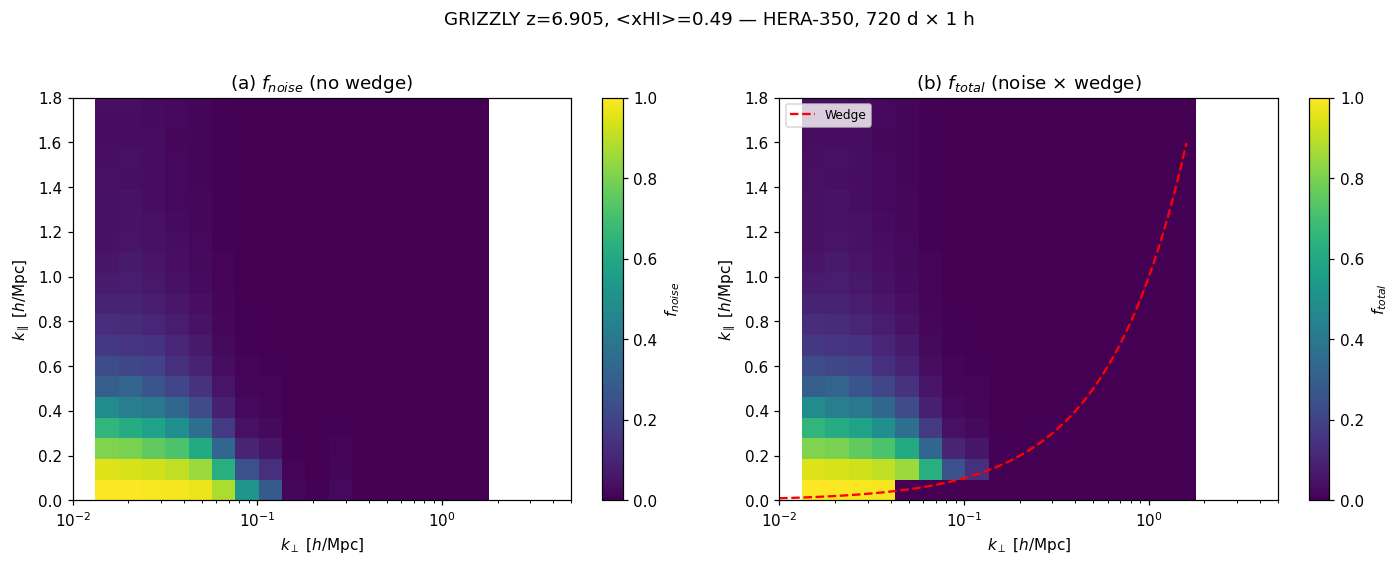

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
kp_line = np.logspace(np.log10(kp_g.min()), np.log10(kp_g.max()), 100)

ax = axes[0]
im = ax.pcolormesh(kp_g * H_PARAM, kpar_g * H_PARAM, f_noise.T,
                    cmap='viridis', vmin=0, vmax=1, shading='auto')
ax.set_xscale('log'); ax.set_xlim(1e-2, 5); ax.set_ylim(0, 1.8)
ax.set_xlabel(r'$k_\perp$ [$h$/Mpc]'); ax.set_ylabel(r'$k_\parallel$ [$h$/Mpc]')
ax.set_title(r'(a) $f_{noise}$ (no wedge)')
plt.colorbar(im, ax=ax, label=r'$f_{noise}$')

ax = axes[1]
im = ax.pcolormesh(kp_g * H_PARAM, kpar_g * H_PARAM, f_total.T,
                    cmap='viridis', vmin=0, vmax=1, shading='auto')
ax.plot(kp_line * H_PARAM, WEDGE_SLOPE * kp_line * H_PARAM, 'r--', lw=1.5, label='Wedge')
ax.set_xscale('log'); ax.set_xlim(1e-2, 5); ax.set_ylim(0, 1.8)
ax.set_xlabel(r'$k_\perp$ [$h$/Mpc]'); ax.set_ylabel(r'$k_\parallel$ [$h$/Mpc]')
ax.set_title(r'(b) $f_{total}$ (noise × wedge)')
ax.legend(loc='upper left', fontsize=8)
plt.colorbar(im, ax=ax, label=r'$f_{total}$')

fig.suptitle(f'GRIZZLY z={z_griz:.3f}, <xHI>={xhi_griz:.2f} — '
             f'HERA-350, {N_DAYS} d × {TRACK_HOURS:g} h',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'../plots/grizzly_filter_z{z_griz:.2f}_{N_DAYS}d_{TRACK_HOURS:g}h.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 4. Wiener denoising

The noisy cube now contains **signal + thermal noise + toy foreground** (a bright
wedge-confined Gaussian field, ~50× signal rms). Real foregrounds are smooth in
frequency, so their power concentrates at low `k_∥` and spills into the wedge
`k_∥ < slope · k_⊥` — this toy model mimics that.

Build a 2D Wiener filter in `(k_x, k_y)` from `P_signal(k_⊥)` and the thermal
`σ_uv²(k_⊥)` (it knows nothing about foregrounds). Apply it to the contaminated
cube, optionally stacked with a 3D wedge mask — that's what actually removes the
foreground. Flat in `k_z`.

In [66]:
# One noisy observed realization (signal + thermal noise, no wedge applied yet)
observed_no_wedge = observe_coeval(
    box=bt_griz * un.mK, box_length=gz.BOX_CROP_MPC * un.Mpc,
    observation=obs, redshift=z_griz, nrealizations=1,
    remove_wedge=False, seed=12345,
)
bt_noisy = observed_no_wedge[0].to(un.mK).value.astype(np.float32)
bt_noisy = np.nan_to_num(bt_noisy, nan=0.0, posinf=0.0, neginf=0.0)

# ── Add a toy foreground: a Gaussian field confined to the wedge region ──
# Real Galactic/extragalactic foregrounds are smooth in frequency → low k_z power,
# which leaks into the wedge (k_par < slope * k_perp). We mimic that by drawing a
# Gaussian cube, keeping only modes inside the wedge, and coloring with k_perp^-1
# so it has spatial correlation. Amplitude is set relative to signal std.
FG_AMPLITUDE_MULT = 50.0   # foreground std = FG_AMPLITUDE_MULT × clean signal std

rng_fg = np.random.default_rng(54321)
fg_white = rng_fg.standard_normal(bt_griz.shape).astype(np.float32)
fg_k = fft.rfftn(fg_white, workers=-1)

# k grids (re-build here so this cell is self-contained)
_ncells = bt_griz.shape[0]
_dk = 2 * np.pi / gz.BOX_CROP_MPC
_kx = _dk * np.fft.fftfreq(_ncells, d=1.0 / _ncells)
_ky = _dk * np.fft.fftfreq(_ncells, d=1.0 / _ncells)
_kz = _dk * np.fft.rfftfreq(_ncells, d=1.0 / _ncells)
_kx3, _ky3, _kz3 = np.meshgrid(_kx, _ky, _kz, indexing='ij')
_kperp_3d = np.sqrt(_kx3 ** 2 + _ky3 ** 2)

inside_wedge = (np.abs(_kz3) <= WEDGE_SLOPE * _kperp_3d).astype(np.float32)
color = 1.0 / np.maximum(_kperp_3d, _dk)          # k_perp^-1 coloring
fg_k_shaped = fg_k * inside_wedge * color
bt_fg = np.real(fft.irfftn(fg_k_shaped, s=bt_griz.shape, workers=-1)).astype(np.float32)

# Normalize to target amplitude
bt_fg *= (FG_AMPLITUDE_MULT * bt_griz.std()) / (bt_fg.std() + 1e-12)

bt_noisy = bt_noisy + bt_fg

print(f'Foreground: std = {bt_fg.std():.2f} mK  ({FG_AMPLITUDE_MULT}× clean signal)')
print(f'Noisy cube (sig + noise + fg): '
      f'mean={bt_noisy.mean():+.3f} mK  std={bt_noisy.std():.3f} mK  '
      f'(clean std={bt_griz.std():.3f} mK)')

Foreground: std = 585.62 mK  (50.0× clean signal)
Noisy cube (sig + noise + fg): mean=+0.720 mK  std=595.446 mK  (clean std=11.712 mK)


In [67]:
# ── Build the Wiener filter directly on the rfftn grid ──
# Thermal noise is flat in k_z → P_noise depends only on k_perp.
# Use the 1D P_noise(k_perp) already computed by empirical_noise_2d above.
ncells = bt_griz.shape[0]
dk = 2 * np.pi / gz.BOX_CROP_MPC
kx = dk * np.fft.fftfreq(ncells, d=1.0 / ncells)
ky = dk * np.fft.fftfreq(ncells, d=1.0 / ncells)
kz = dk * np.fft.rfftfreq(ncells, d=1.0 / ncells)
kx3, ky3, kz3 = np.meshgrid(kx, ky, kz, indexing='ij')
kperp_3d = np.sqrt(kx3 ** 2 + ky3 ** 2)

# Interpolate P_noise(k_perp) from the 1D spectrum; unsampled modes → large value
P_n_1d_safe = np.where(np.isfinite(P_n_1d) & (P_n_1d > 0), P_n_1d, 1e30)
P_noise_3d = np.interp(kperp_3d, kp_g, P_n_1d_safe).astype(np.float32)

# P_signal per voxel from the clean box
bt_k = fft.rfftn(bt_griz - bt_griz.mean(), workers=-1)
V = gz.BOX_CROP_MPC ** 3
P_signal_3d = (np.abs(bt_k) ** 2 / V).astype(np.float32)

# Wiener filter at each rfftn voxel
wiener_3d = np.where(
    (P_signal_3d + P_noise_3d) > 0,
    P_signal_3d / (P_signal_3d + P_noise_3d),
    0.0,
).astype(np.float32)

# 3D wedge mask on the same rfftn grid
wedge_3d = (np.abs(kz3) > WEDGE_SLOPE * kperp_3d).astype(np.float32)

print(f'Wiener filter (3D rfft grid): min={wiener_3d.min():.3f}  max={wiener_3d.max():.3f}')
print(f'  voxels with w > 0.5: {(wiener_3d > 0.5).sum():,} / {wiener_3d.size:,}')

Wiener filter (3D rfft grid): min=0.000  max=1.000
  voxels with w > 0.5: 13,465 / 79,023,600


In [68]:
def apply_filter_3d(box, w3d, wedge_3d=None):
    """Apply a 3D filter in rfftn space, optionally combined with a wedge mask."""
    box_k = fft.rfftn(box - box.mean(), workers=-1)
    filt = w3d
    if wedge_3d is not None:
        filt = filt * wedge_3d
    return np.real(fft.irfftn(box_k * filt, s=box.shape, workers=-1)).astype(np.float32)

bt_wiener       = apply_filter_3d(bt_noisy, wiener_3d)
bt_wiener_wedge = apply_filter_3d(bt_noisy, wiener_3d, wedge_3d)

def rms_resid(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

clean_ms = bt_griz - bt_griz.mean()
print('RMS residual vs clean signal [mK]:')
print(f'  noisy                  : {rms_resid(bt_noisy - bt_noisy.mean(), clean_ms):.3f}')
print(f'  Wiener (no wedge)      : {rms_resid(bt_wiener,        clean_ms):.3f}')
print(f'  Wiener + wedge mask    : {rms_resid(bt_wiener_wedge,  clean_ms):.3f}')

RMS residual vs clean signal [mK]:
  noisy                  : 595.515
  Wiener (no wedge)      : 106.593
  Wiener + wedge mask    : 11.486


## 5. Brightness-temperature maps (mid-slice)

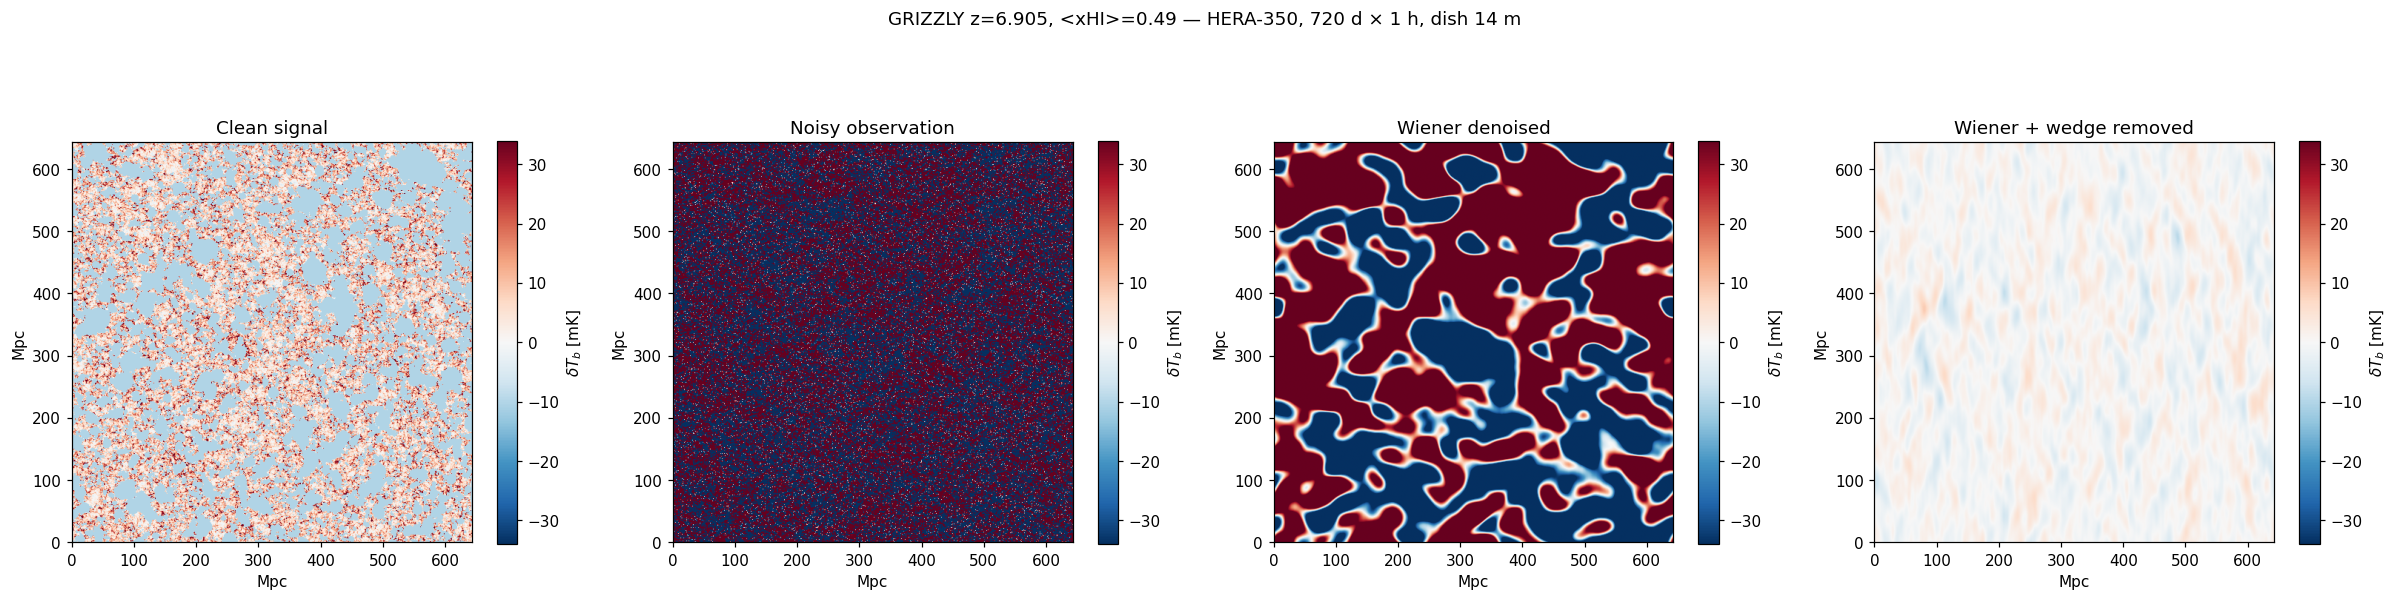

In [69]:
mid = bt_griz.shape[0] // 2
# Use the clean signal range for a fair visual comparison
vmax = float(np.percentile(np.abs(bt_griz[mid] - bt_griz.mean()), 99))

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
panels = [
    ('Clean signal',               bt_griz[mid] - bt_griz.mean()),
    ('Noisy observation',          bt_noisy[mid] - bt_noisy.mean()),
    ('Wiener denoised',            bt_wiener[mid]),
    ('Wiener + wedge removed',     bt_wiener_wedge[mid]),
]
for ax, (title, img) in zip(axes, panels):
    im = ax.imshow(img, extent=[0, gz.BOX_CROP_MPC, 0, gz.BOX_CROP_MPC],
                   origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel('Mpc'); ax.set_ylabel('Mpc')
    plt.colorbar(im, ax=ax, label=r'$\delta T_b$ [mK]', shrink=0.75)

fig.suptitle(f'GRIZZLY z={z_griz:.3f}, <xHI>={xhi_griz:.2f} — '
             f'HERA-350, {N_DAYS} d × {TRACK_HOURS:g} h, dish {DISH_M:.0f} m',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'../plots/grizzly_wiener_tb_z{z_griz:.2f}_{N_DAYS}d_{TRACK_HOURS:g}h.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 6. Velocity reconstruction and kSZ cross-correlation

For each of the 4 brightness-temperature scenarios (clean, noisy, Wiener,
Wiener + wedge), use the field as a tracer to reconstruct the LOS velocity via
the continuity equation, project to a 2D kSZ map, and cross-correlate against
the "true" kSZ built from the simulation's own `v_z`.

Pipeline ported from notebook `01` (§7).

In [70]:
from powerbox import get_power

# ── Physical constants ──
_SIGMA_T   = 6.6524587158e-25    # Thomson cross-section [cm^2]
_C_KM_S    = 2.99792458e5        # c [km/s]
_T_CMB     = 2.725e6             # CMB temp [µK]
_M_P       = 1.6726219e-24       # proton mass [g]
_MPC_TO_CM = 3.085677581e24

# ── GRIZZLY cosmology (h=0.7, Omega_m=0.27) ──
H_KSZ   = 0.7
OMEGA_M = 0.27
OMEGA_B = 0.045


def reconstruct_velocity_z(density, z, box_len, h=H_KSZ, omega_m=OMEGA_M,
                           tracer_field=None):
    """Continuity-equation velocity reconstruction from a tracer field.
    v_z(k) = a * H(z) * f(z) * i k_z * T(k) / k^2"""
    n = density.shape[0]
    a = 1.0 / (1.0 + z)
    H0 = 100.0 * h
    omega_l = 1.0 - omega_m
    H_z = H0 * np.sqrt(omega_m * (1 + z) ** 3 + omega_l)
    omega_m_z = omega_m * (1 + z) ** 3 / (omega_m * (1 + z) ** 3 + omega_l)
    f_growth = omega_m_z ** 0.55

    field = tracer_field if tracer_field is not None else density
    field = np.asarray(field, dtype=np.float64)
    field = field - field.mean()
    field_k = fft.rfftn(field, workers=-1)

    dk = 2.0 * np.pi / box_len
    kx = dk * np.fft.fftfreq(n, d=1.0 / n)
    ky = dk * np.fft.fftfreq(n, d=1.0 / n)
    kz = dk * np.fft.rfftfreq(n, d=1.0 / n)
    kx3, ky3, kz3 = np.meshgrid(kx, ky, kz, indexing='ij')
    k2 = kx3 ** 2 + ky3 ** 2 + kz3 ** 2
    k2[0, 0, 0] = 1.0
    v_z_k = (a * H_z * f_growth) * 1j * kz3 * field_k / k2
    v_z_k[0, 0, 0] = 0.0
    return np.real(fft.irfftn(v_z_k, s=(n, n, n), workers=-1)).astype(np.float32)


def compute_ksz_map(vz, xHI, delta, z, box_len, h=H_KSZ, omega_b=OMEGA_B, axis=2):
    """Project kSZ along LOS from density+xHI+v_z. `delta` is overdensity, `vz` in km/s."""
    n_cells = delta.shape[axis]
    Y_He = 0.24
    X_H  = 1.0 - Y_He
    rho_crit_0 = 1.8788e-29 * h ** 2
    rho_b_0    = omega_b * rho_crit_0
    n_e_0 = rho_b_0 / _M_P * (1.0 + X_H) / 2.0
    n_e_z = n_e_0 * (1.0 + z) ** 3
    dl_cm = (box_len / (1.0 + z)) / n_cells * _MPC_TO_CM
    pref  = -_T_CMB * _SIGMA_T * n_e_z * dl_cm / _C_KM_S

    x_e = 1.0 - np.clip(xHI, 0.0, 1.0)
    return (pref * np.sum(x_e * (1.0 + delta) * vz, axis=axis)).astype(np.float32)


def cross_correlate_2d(map1, map2, box_len, bins=50):
    """r(k) and real-space Pearson r between two 2D maps."""
    f1 = (map1 - map1.mean()).astype(np.float64)
    f2 = (map2 - map2.mean()).astype(np.float64)
    bl = [box_len, box_len]
    kw = dict(boxlength=bl, bins=bins, ignore_zero_mode=True, dimensionless=False)
    res11 = get_power(deltax=f1, **kw)
    res22 = get_power(deltax=f2, **kw)
    res12 = get_power(deltax=f1, deltax2=f2, **kw)
    P_11, k = res11[0], res11[1]
    P_22 = res22[0]
    P_12 = res12[0]
    denom = np.sqrt(np.abs(P_11 * P_22))
    r_k = np.where(denom > 0, P_12 / denom, 0.0)
    r_real = float(np.sum(f1 * f2) / np.sqrt(np.sum(f1 ** 2) * np.sum(f2 ** 2)))
    return k, r_k, r_real


print('kSZ pipeline functions loaded.')

kSZ pipeline functions loaded.


In [71]:
# Build the true kSZ map from the simulation velocity
delta_g = (den_g / den_g.mean() - 1.0).astype(np.float32)         # overdensity
vz_true_kms = (vz_g_cms * 1e-5).astype(np.float32)                # cm/s → km/s

ksz_true = compute_ksz_map(vz_true_kms, xhi_g, delta_g, z_griz, gz.BOX_CROP_MPC)
print(f'vz (true):   std = {vz_true_kms.std():.1f} km/s')
print(f'kSZ (true):  mean={ksz_true.mean():+.3e} µK, std={ksz_true.std():.3e} µK')

vz (true):   std = 148.1 km/s
kSZ (true):  mean=+1.480e-01 µK, std=2.027e+00 µK


In [72]:
# Run velocity reconstruction + kSZ cross-correlation for all 4 scenarios
scenarios = [
    ('Clean signal',             bt_griz),
    ('Noisy observation',        bt_noisy),
    ('Wiener denoised',          bt_wiener),
    ('Wiener + wedge removed',   bt_wiener_wedge),
]

results = {}
for label, tracer in scenarios:
    vz_rec = reconstruct_velocity_z(delta_g, z_griz, gz.BOX_CROP_MPC,
                                     tracer_field=tracer)
    ksz_rec = compute_ksz_map(vz_rec, xhi_g, delta_g, z_griz, gz.BOX_CROP_MPC)
    k, r_k, r_real = cross_correlate_2d(ksz_true, ksz_rec, gz.BOX_CROP_MPC)
    results[label] = dict(vz_rec=vz_rec, ksz_rec=ksz_rec, k=k, r_k=r_k, r_real=r_real)
    print(f'{label:27s}  real-space r = {r_real:+.4f}')

/Users/jelte/Documents/PhD/noise_analysis/.venv/lib/python3.11/site-packages/powerbox/tools.py:307: FutureWarning: In the future, bins will be generated by default up to the smallest length over any dimension, instead of the largest magnitude for the box.Set bins_upto_boxlen to silence this warning.
  bins = _getbins(bins, coord_mags, log_bins, bins_upto_boxlen=bins_upto_boxlen)


Clean signal                 real-space r = -0.6216
Noisy observation            real-space r = -0.0730
Wiener denoised              real-space r = -0.0650
Wiener + wedge removed       real-space r = -0.4424


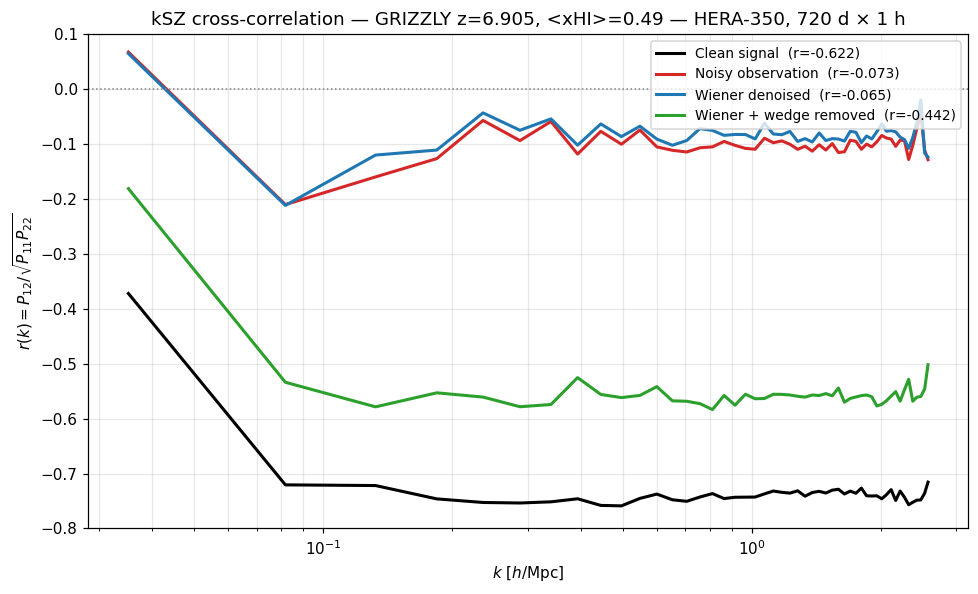

In [73]:
# r(k) curves for all 4 scenarios
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ['k', 'C3', 'C0', 'C2']
for (label, _), c in zip(scenarios, colors):
    r = results[label]
    ax.plot(r['k'] * H_PARAM, r['r_k'], c + '-', lw=2,
            label=f'{label}  (r={r["r_real"]:+.3f})')

ax.axhline(0.0, color='gray', ls=':', lw=1)
ax.axhline(1.0, color='gray', ls=':', lw=1)
ax.set_xscale('log')
ax.set_xlabel(r'$k$ [$h$/Mpc]')
ax.set_ylabel(r'$r(k) = P_{12}/\sqrt{P_{11} P_{22}}$')
ax.set_title(f'kSZ cross-correlation — GRIZZLY z={z_griz:.3f}, <xHI>={xhi_griz:.2f} — '
             f'HERA-350, {N_DAYS} d × {TRACK_HOURS:g} h')
ax.set_ylim(-0.8, 0.1)
ax.legend(fontsize=9, loc='upper right'); ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(f'../plots/grizzly_ksz_rk_z{z_griz:.2f}_{N_DAYS}d_{TRACK_HOURS:g}h.png',
            dpi=150, bbox_inches='tight')
plt.show()

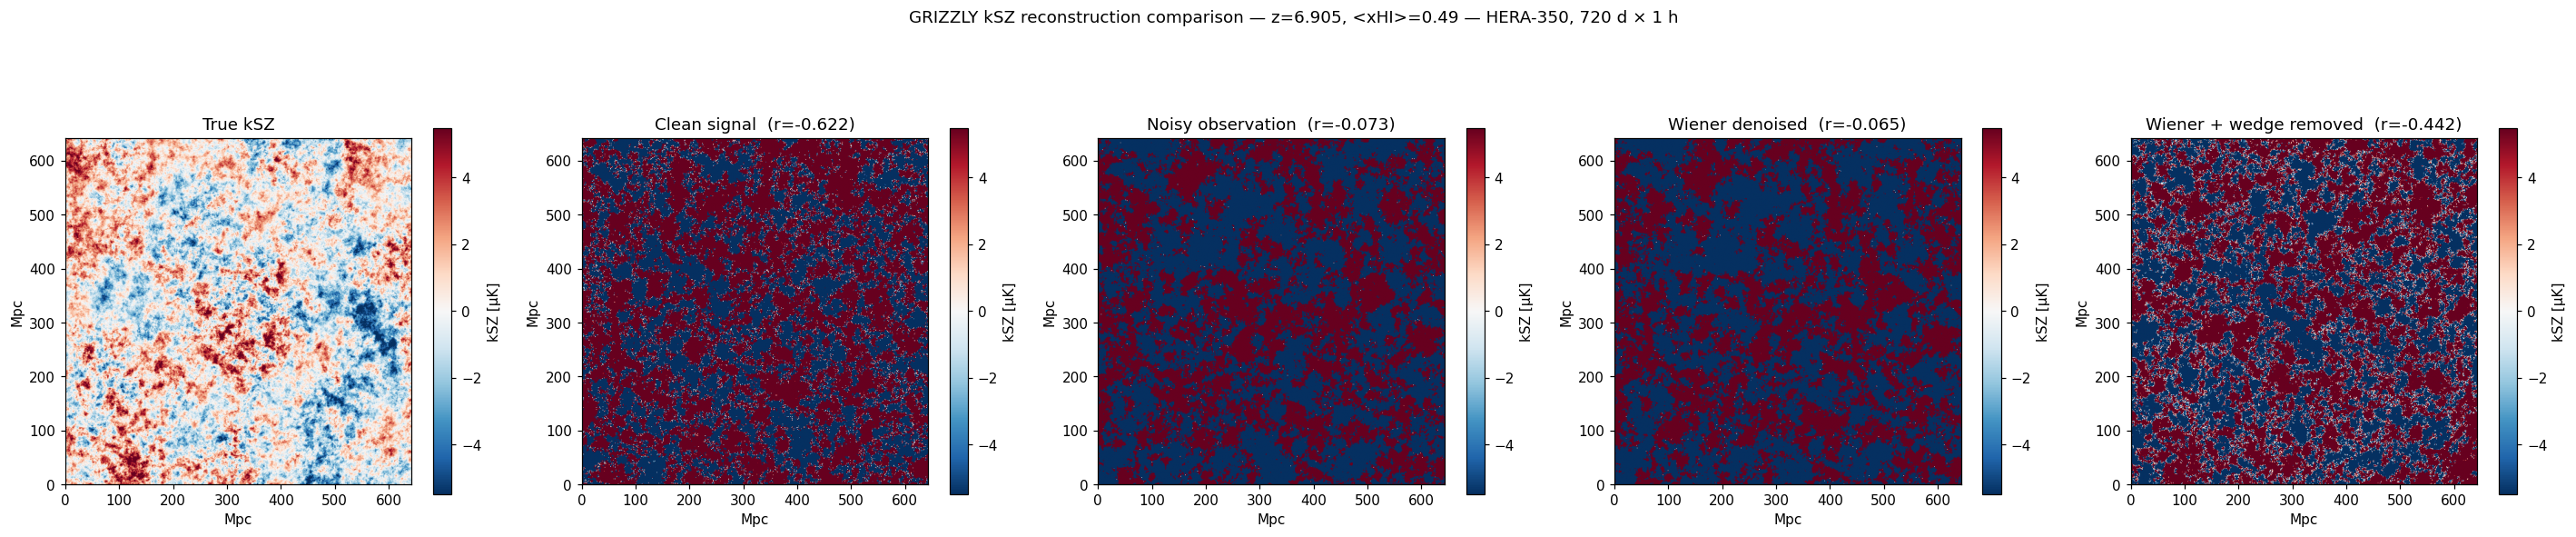

In [74]:
# kSZ map comparison: true vs each of the 4 reconstructions
# Use a robust color scale based on the true kSZ 99th percentile
vmax = float(np.percentile(np.abs(ksz_true), 99))

fig, axes = plt.subplots(1, 5, figsize=(26, 5.5))
panels = [('True kSZ', ksz_true)] + [
    (label, results[label]['ksz_rec']) for label, _ in scenarios
]
for ax, (title, img) in zip(axes, panels):
    im = ax.imshow(img, extent=[0, gz.BOX_CROP_MPC, 0, gz.BOX_CROP_MPC],
                   origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    sub = '' if title == 'True kSZ' else f'  (r={results[title]["r_real"]:+.3f})'
    ax.set_title(f'{title}{sub}')
    ax.set_xlabel('Mpc'); ax.set_ylabel('Mpc')
    plt.colorbar(im, ax=ax, label=r'kSZ [µK]', shrink=0.75)

fig.suptitle(f'GRIZZLY kSZ reconstruction comparison — z={z_griz:.3f}, <xHI>={xhi_griz:.2f} — '
             f'HERA-350, {N_DAYS} d × {TRACK_HOURS:g} h',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'../plots/grizzly_ksz_maps_z{z_griz:.2f}_{N_DAYS}d_{TRACK_HOURS:g}h.png',
            dpi=150, bbox_inches='tight')
plt.show()